In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from src.python import tech_colors, ssp_colors

# Set LaTeX style
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif'],
    'mathtext.fontset': 'stix',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'legend.fontsize': 10,
    'legend.title_fontsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.4,
    'grid.alpha': 0.2,
    'lines.linewidth': 1.5,
})


# 1. Data extraction

In [2]:

# td_production_old = td_production.copy()
td_production = pd.read_csv("output/operations/production_details.csv")
td_production = td_production[["SSP","Decade","Technology","Day","Hour","Balance"]].groupby(["SSP","Decade","Technology","Day","Hour"]).sum().reset_index().rename(columns = {'Balance':'Value'})

In [3]:
# Load data

tech_order = ['GSHP', 'ASHP', 'E_boiler', 'NG_boiler']  # Your desired order
tech_cat = pd.CategoricalDtype(tech_order, ordered=True)
td_production['Technology'] = td_production['Technology'].astype(tech_cat)

td_production = td_production.sort_values(['SSP', 'Decade', 'Day', 'Hour', 'Technology'])

td_losses = pd.read_csv("output/operations/TD_losses.csv")
td_weight = pd.read_csv("data/inputs/preprocessed_weights.csv")[['gcm','ssp','decade','td','weight']].rename(columns={'ssp':'SSP','decade':'Decade','td':'Day'})
td_weight = td_weight[['SSP','Decade','Day','weight']].groupby(['SSP','Decade','Day']).mean().reset_index()

mask = td_weight['Decade'] == '2020s'
past_weight = td_weight[mask][['Decade','Day','weight']].groupby(['Decade','Day']).mean().reset_index()
past_weight['SSP'] = 'past'
future_weight = td_weight[~mask][['SSP','Decade','Day','weight']].groupby(['SSP','Decade','Day']).mean().reset_index()

td_weight = pd.concat([past_weight,future_weight])
print(pd.concat([past_weight,future_weight]))
td_production

    Decade  Day      weight     SSP
0    2020s    0   83.750000    past
1    2020s    1  228.500000    past
2    2020s    2  374.458333    past
3    2020s    3  433.291667    past
4    2020s    4  322.541667    past
..     ...  ...         ...     ...
507  2100s   11   18.200000  ssp585
508  2100s   12   24.400000  ssp585
509  2100s   13   31.800000  ssp585
510  2100s   14   32.200000  ssp585
511  2100s   15   30.800000  ssp585

[528 rows x 4 columns]


,SSP,Decade,Technology,Day,Hour,Value
768,past,2020s,GSHP,0,0,0.000000
0,past,2020s,ASHP,0,0,0.000000
384,past,2020s,E_boiler,0,0,0.000000
1152,past,2020s,NG_boiler,0,0,0.000000
769,past,2020s,GSHP,0,1,0.000000
...,...,...,...,...,...,...
44542,ssp585,2090s,NG_boiler,15,22,0.000000
44159,ssp585,2090s,GSHP,15,23,-711.111111
43391,ssp585,2090s,ASHP,15,23,-2011.731913
43775,ssp585,2090s,E_boiler,15,23,0.000000


In [4]:
SSP = 'ssp126'
ssp_formatted = f"SSP{SSP[3]}-{SSP[4]}.{SSP[5]}"
Decade = '2030s'

# 3. Aggregation per day

/var/folders/_8/5wkhjk491lg_89k0811g6vlm0000gn/T/ipykernel_63632/3337853547.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_data_prod = td_production[mask2].pivot_table(index='Day', columns='Technology', values='Value', aggfunc='sum')


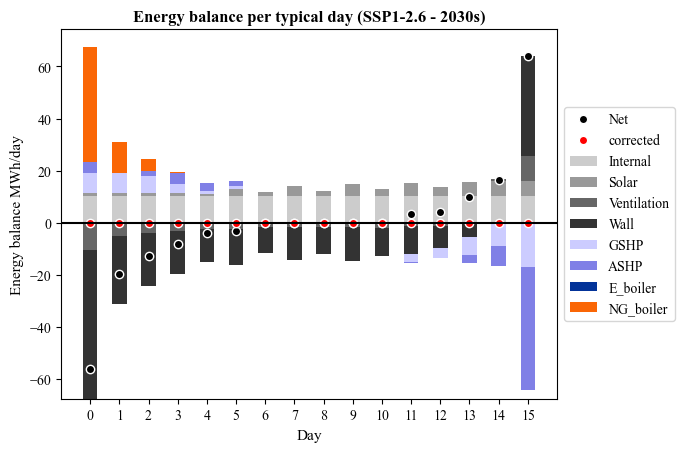

In [5]:
# color losses
loss_types = td_losses['Loss_type'].unique()
n_types = len(loss_types)
grey_shades = np.linspace(0.2, 0.8, n_types)  # Range from dark to light grey
loss_type_colors = {loss_type: str(shade) for loss_type, shade in zip(loss_types, grey_shades)}

# color production
prod_type = ['GSHP','ASHP','E_boiler','NG_boiler']

combined_colors = {**loss_type_colors, **tech_colors}

mask = (td_losses['SSP'] == SSP) * (td_losses['Decade'] == Decade)
pivot_data_loss = td_losses[mask].pivot_table(index='Day', columns='Loss_type', values='Value', aggfunc='sum')

mask2 = (td_production['SSP'] == SSP) * (td_production['Decade'] == Decade)
pivot_data_prod = td_production[mask2].pivot_table(index='Day', columns='Technology', values='Value', aggfunc='sum')

res = pd.merge(pivot_data_loss,pivot_data_prod, left_index = True, right_index = True) / 1000

res.plot(kind='bar', stacked=True, color=[combined_colors[col] for col in res.columns])
(pivot_data_loss / 1000).sum(axis=1).plot(marker='o', linestyle='', color='k', markeredgecolor = 'white', label = 'Net')
res.sum(axis=1).plot(marker='o', linestyle='', color='red', markeredgecolor = 'white', label = 'corrected')

plt.hlines(xmin=td_losses['Day'].min()-1, xmax=td_losses['Day'].max()+1, y=0, color='k')
plt.xlim(td_losses['Day'].min()-1, td_losses['Day'].max()+1)

plt.title(f"Energy balance per typical day ({ssp_formatted} - {Decade})")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel('Energy balance MWh/day')
plt.savefig('output/operations/TD_balance.png',dpi = 600)

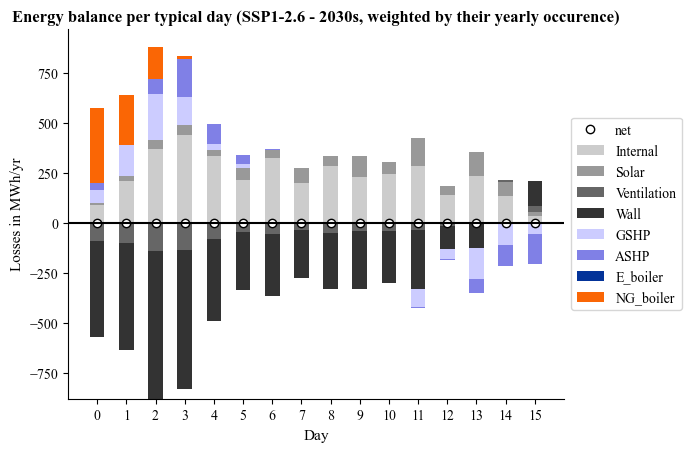

In [6]:
df = pd.concat([td_losses.rename(columns={'Loss_type':'Origin'}),td_production.rename(columns={'Technology':'Origin'})], axis = 0)
processed_weight = td_weight
joined_df = df.merge(processed_weight, on=['SSP', 'Decade', 'Day'])
joined_df['Value'] = joined_df['Value'] * joined_df['weight'] / 10 / 1e3 # / 10 years / 1000 kWh -> MWh


mask = (joined_df['SSP'] == SSP) * (joined_df['Decade'] == Decade)

pivot_data = joined_df[mask].sort_values(['SSP', 'Decade', 'Day', 'Hour', 'Origin']).pivot_table(index='Day', columns='Origin', values='Value', aggfunc='sum')

ordered_cols = ['Internal','Solar','Ventilation','Wall','GSHP','ASHP','E_boiler','NG_boiler']
ax = pivot_data[ordered_cols].plot(kind='bar', stacked=True, color=[combined_colors[col] for col in ordered_cols])
pivot_data.sum(axis=1).plot(marker='o', linestyle='', color='white', markeredgecolor = 'black', label = 'net')

plt.title(f"Energy balance per typical day ({ssp_formatted} - {Decade}, weighted by their yearly occurence)")
plt.hlines(xmin=joined_df['Day'].min()-1, xmax=joined_df['Day'].max()+1, y=0, color='k')
plt.xlim(joined_df['Day'].min()-1, joined_df['Day'].max()+1)
plt.ylabel('Losses in MWh/yr')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
plt.savefig('output/operations/TD_balance_weighted.png',dpi = 600)

# 4. Aggregation per scenario

/var/folders/_8/5wkhjk491lg_89k0811g6vlm0000gn/T/ipykernel_63632/97246862.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['SSP', 'Decade', 'Technology']).agg({


['ssp126' 'ssp245' 'ssp370' 'ssp585']
['2020s', '2030s', '2040s', '2050s', '2060s', '2070s', '2080s', '2090s']
['GSHP', 'ASHP', 'E_boiler', 'NG_boiler']
Categories (4, object): ['GSHP' < 'ASHP' < 'E_boiler' < 'NG_boiler']
0 GSHP
1 ASHP
2 E_boiler
3 NG_boiler
0 GSHP
1 ASHP
2 E_boiler
3 NG_boiler
0 GSHP
1 ASHP
2 E_boiler
3 NG_boiler
0 GSHP
1 ASHP
2 E_boiler
3 NG_boiler


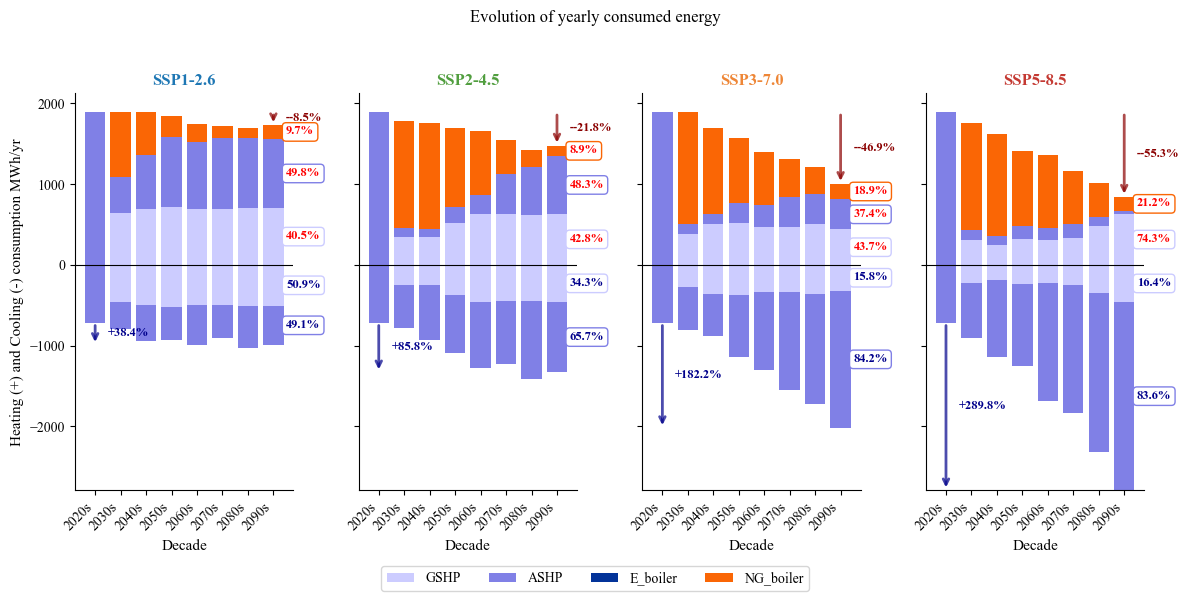

In [7]:
joined_df = td_production.merge(td_weight, on=['SSP', 'Decade', 'Day'])

joined_df['Value'] = joined_df['Value'] * joined_df['weight'] / 10 / 1e3 # / 10 years / 1000 kWh -> MWh
df = joined_df.copy()
# Prepare data: separate positive and negative values
df['Value_Pos'] = df['Value'].where(df['Value'] >= 0, 0)
df['Value_Neg'] = df['Value'].where(df['Value'] < 0, 0)
# Group by SSP, Decade, Technology and sum positive/negative values
grouped = df.groupby(['SSP', 'Decade', 'Technology']).agg({
    'Value_Pos': 'sum',
    'Value_Neg': 'sum'
}).reset_index()
# Get unique SSPs and Decades
ssps = df[df['SSP'] != 'past']['SSP'].unique()
print(ssps)
decades = sorted(df['Decade'].unique())
print(decades)
techs = (df['Technology'].unique())
print(techs)
# Create subplots
fig, axes = plt.subplots(1, len(ssps), figsize=(3*len(ssps), 6), sharey=True)
if len(ssps) == 1:
    axes = [axes]
# Create bar plots for each SSP
for idx, ssp in enumerate(ssps):
    ax = axes[idx]
    ssp_data = grouped[(grouped['SSP'] == ssp) | (grouped['SSP'] == 'past')]
    # Prepare data for stacking
    pos_stacks = []
    neg_stacks = []
    for tech in techs:
        tech_data = ssp_data[ssp_data['Technology'] == tech]
        tech_summed = tech_data.groupby('Decade').agg({
            'Value_Pos': 'sum',
            'Value_Neg': 'sum'
        }).reset_index()
        # Align with decades
        tech_dict = dict(zip(tech_summed['Decade'], tech_summed['Value_Pos']))
        pos_stacks.append([tech_dict.get(dec, 0) for dec in decades])
        tech_dict = dict(zip(tech_summed['Decade'], tech_summed['Value_Neg']))
        neg_stacks.append([tech_dict.get(dec, 0) for dec in decades])
    
    # Convert to numpy arrays for easier computation
    pos_stacks = np.array(pos_stacks)
    neg_stacks = np.array(neg_stacks)
    
    # Calculate totals for first and last decade (separately for pos and neg)
    first_total_pos = pos_stacks[:, 0].sum()
    last_total_pos = pos_stacks[:, -1].sum()
    first_total_neg = neg_stacks[:, 0].sum()
    last_total_neg = neg_stacks[:, -1].sum()
    
    # Plot positive stacks (upward)
    bottom_pos = np.zeros(len(decades))
    for i, tech in enumerate(techs):
        print(i, tech)
        ax.bar(decades, pos_stacks[i], bottom=bottom_pos, 
               color=tech_colors[tech], label=tech)
        bottom_pos += pos_stacks[i]
    
    # Plot negative stacks (downward)
    bottom_neg = np.zeros(len(decades))
    for i, tech in enumerate(techs):
        ax.bar(decades, neg_stacks[i], bottom=bottom_neg, 
               color=tech_colors[tech])
        bottom_neg += neg_stacks[i]
    
    # Add arrow for positive values (from first to last decade total)
    first_decade_x = 0  # Position of first decade
    last_decade_x = len(decades) - 1  # Position of last decade
    
    if first_total_pos != 0 or last_total_pos != 0:
        ax.annotate('', xy=(last_decade_x, last_total_pos), xytext=(last_decade_x, first_total_pos),
                    arrowprops=dict(arrowstyle='->', lw=2, color='darkred', alpha=0.7))
        
        ax.text(last_decade_x+0.5, 0.5*(last_total_pos+first_total_pos), f'-{100*(last_total_pos-first_total_pos)/first_total_pos:.1f}%', 
                ha='left', va='center', fontsize=9, fontweight='bold',
                color='darkred')
    
    # Add arrow for negative values (from first to last decade total)
    if first_total_neg != 0 or last_total_neg != 0:
        ax.annotate('', xy=(first_decade_x, last_total_neg), xytext=(first_decade_x, first_total_neg),
                    arrowprops=dict(arrowstyle='->', lw=2, color='darkblue', alpha=0.7))
        
        ax.text(first_decade_x+0.5, 0.5*(last_total_neg+first_total_neg), f'+{100*(last_total_neg-first_total_neg)/first_total_neg:.1f}%', 
                ha='left', va='center', fontsize=9, fontweight='bold',
                color='darkblue')
        
    # Add percentage annotations for last decade - POSITIVE values
    last_pos_stack = pos_stacks[:, -1]
    
    if last_total_pos != 0:
        bottom = 0
        for i, tech in enumerate(techs):
            value = last_pos_stack[i]
            if value != 0:  # Only annotate if there's a value
                percentage = (value / last_total_pos) * 100
                y_position = bottom + value / 2
                if percentage > 5:
                    ax.text(last_decade_x+0.5, y_position, f'{percentage:.1f}%', 
                        ha='left', va='center', fontsize=9, fontweight='bold',
                        color='red',
                        bbox=dict(facecolor='white', edgecolor=tech_colors[tech], 
                                    boxstyle='round,pad=0.3'))
                bottom += value
    
    # Add percentage annotations for last decade - NEGATIVE values
    last_neg_stack = neg_stacks[:, -1]
    
    if last_total_neg != 0:
        bottom = 0
        for i, tech in enumerate(techs):
            value = last_neg_stack[i]
            if value != 0:  # Only annotate if there's a value
                percentage = (value / last_total_neg) * 100
                y_position = bottom + value / 2
                if percentage > 5:
                    ax.text(last_decade_x+0.5, y_position, f'{percentage:.1f}%', 
                        ha='left', va='center', fontsize=9, fontweight='bold',
                        color='darkblue',
                        bbox=dict(facecolor='white', edgecolor=tech_colors[tech], 
                                    boxstyle='round,pad=0.3'))
                bottom += value
    
    ssp_formatted = f"SSP{ssp[3]}-{ssp[4]}.{ssp[5]}"
    ax.set_title(f'{ssp_formatted}', fontdict={'color':ssp_colors[ssp_formatted]})
    ax.set_xlabel('Decade')
    if idx == 0:
        ax.set_ylabel('Heating (+) and Cooling (-) consumption MWh/yr')
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_xticks(decades)
    ax.set_xticklabels(decades, rotation=45, ha='right')
    # Remove the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)

# Add legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(techs), bbox_to_anchor=(0.5, -0.00))
fig.suptitle('Evolution of yearly consumed energy')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])

plt.savefig('output/operations/ssp_view_energy.png',dpi = 600, bbox_inches='tight')
plt.savefig('output/operations/ssp_view_energy.pdf', bbox_inches='tight')

          SSP Decade Technology  Day     Sign  Hour  Value  weight
0        past  2020s       ASHP    0  Cooling     0    0.0   83.75
1        past  2020s       ASHP    0  Cooling     1    0.0   83.75
2        past  2020s       ASHP    0  Cooling     2    0.0   83.75
3        past  2020s       ASHP    0  Cooling     3    0.0   83.75
4        past  2020s       ASHP    0  Cooling     4    0.0   83.75
...       ...    ...        ...  ...      ...   ...    ...     ...
66811  ssp585  2090s  NG_boiler   15  Heating    19    0.0  269.00
66812  ssp585  2090s  NG_boiler   15  Heating    20    0.0  269.00
66813  ssp585  2090s  NG_boiler   15  Heating    21    0.0  269.00
66814  ssp585  2090s  NG_boiler   15  Heating    22    0.0  269.00
66815  ssp585  2090s  NG_boiler   15  Heating    23    0.0  269.00

[66816 rows x 8 columns]
['ssp126' 'ssp245' 'ssp370' 'ssp585']
['2020s', '2030s', '2040s', '2050s', '2060s', '2070s', '2080s', '2090s']
['ASHP' 'E_boiler' 'GSHP' 'NG_boiler']
['Cooling' 'Heating'

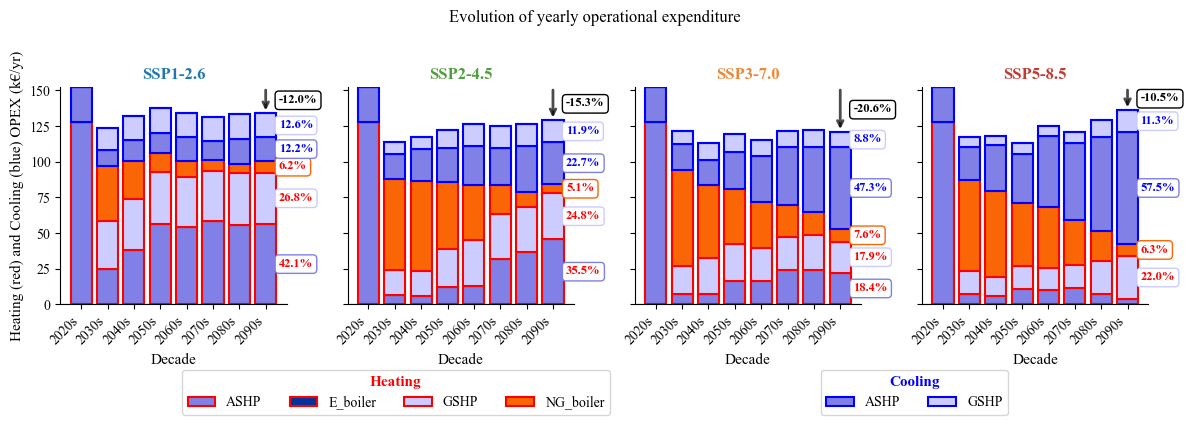

In [8]:
td_opex = pd.read_csv("output/operations/production_details.csv")
td_opex = td_opex[["SSP","Decade","Technology","Day","Hour","Sign","OPEX"]].groupby(["SSP","Decade","Technology","Day","Sign","Hour"]).sum().reset_index().rename(columns = {'OPEX':'Value'})

joined_df = td_opex.merge(td_weight, on=['SSP', 'Decade', 'Day'])
print(joined_df)
joined_df['Value'] = joined_df['Value'] * joined_df['weight'] / 10 / 1e3 # / 10 years / 1000 kWh -> MWh
df = joined_df.copy()

# Group by SSP, Decade, Technology, Sign and sum values
grouped = df.groupby(['SSP', 'Decade', 'Technology', 'Sign']).agg({
    'Value': 'sum'
}).reset_index()

# Get unique SSPs, Decades, Technologies, and Signs
ssps = df[df['SSP'] != 'past']['SSP'].unique()
print(ssps)
decades = sorted(df['Decade'].unique())
print(decades)
techs = df['Technology'].unique()
print(techs)
signs = df['Sign'].unique()
print(signs)

# Create subplots
fig, axes = plt.subplots(1, len(ssps), figsize=(3*len(ssps), 4), sharey=True)
if len(ssps) == 1:
    axes = [axes]

# Create bar plots for each SSP
for idx, ssp in enumerate(ssps):
    ax = axes[idx]
    ssp_data = grouped[(grouped['SSP'] == ssp) | (grouped['SSP'] == 'past')]
    print(ssp_data)
    
    # Prepare data for stacking - separate by Sign (Heating/Cooling)
    heating_stacks = []
    cooling_stacks = []
    
    for tech in techs:
        tech_data = ssp_data[ssp_data['Technology'] == tech]
        
        # Heating data
        heating_data = tech_data[tech_data['Sign'] == 'Heating']
        heating_summed = heating_data.groupby('Decade').agg({'Value': 'sum'}).reset_index()
        heating_dict = dict(zip(heating_summed['Decade'], heating_summed['Value']))
        heating_stacks.append([heating_dict.get(dec, 0) for dec in decades])
        
        # Cooling data
        cooling_data = tech_data[tech_data['Sign'] == 'Cooling']
        cooling_summed = cooling_data.groupby('Decade').agg({'Value': 'sum'}).reset_index()
        cooling_dict = dict(zip(cooling_summed['Decade'], cooling_summed['Value']))
        cooling_stacks.append([cooling_dict.get(dec, 0) for dec in decades])
    
    # Convert to numpy arrays
    heating_stacks = np.array(heating_stacks)
    cooling_stacks = np.array(cooling_stacks)
    
    # Calculate totals for first and last decade
    first_total_heating = heating_stacks[:, 0].sum()
    last_total_heating = heating_stacks[:, -1].sum()
    first_total_cooling = cooling_stacks[:, 0].sum()
    last_total_cooling = cooling_stacks[:, -1].sum()
    
    # Plot Heating stacks (positive, red edge)
    bottom = np.zeros(len(decades))
    for i, tech in enumerate(techs):
        ax.bar(decades, heating_stacks[i], bottom=bottom, 
               color=tech_colors[tech], label=tech, 
               edgecolor='red', linewidth=1.5)
        bottom += heating_stacks[i]
    
    # Plot Cooling stacks (negative, blue edge)
    # bottom = np.zeros(len(decades))
    for i, tech in enumerate(techs):
        ax.bar(decades, cooling_stacks[i], bottom=bottom, 
               color=tech_colors[tech], edgecolor='blue', linewidth=1.5,label=tech)
        bottom += cooling_stacks[i]
    
    # Add arrow for Heating (from first to last decade total)
    first_decade_x = 0
    last_decade_x = len(decades) - 1
    
    if first_total_heating != 0 or last_total_heating != 0:
        ax.annotate('', xy=(last_decade_x, (last_total_cooling + last_total_heating)), xytext=(last_decade_x, (first_total_cooling+first_total_heating)),
                    arrowprops=dict(arrowstyle='->', lw=2, color='k', alpha=0.7))
        
        if first_total_heating != 0:
            change_pct = 100 * ((last_total_cooling + last_total_heating) - (first_total_cooling+first_total_heating)) / (first_total_cooling+first_total_heating)
            ax.text(last_decade_x+0.5, 0.5*((last_total_cooling + last_total_heating)+(first_total_cooling+first_total_heating)), 
                    f'{change_pct:+.1f}%', 
                    ha='left', va='center', fontsize=9, fontweight='bold',
                    color='black',
                    bbox=dict(facecolor='white', edgecolor='black', 
                                boxstyle='round,pad=0.3'))
    
    
    # Add percentage annotations for last decade - HEATING
    last_heating_stack = heating_stacks[:, -1]
    
    if last_total_heating != 0:
        bottom = 0
        for i, tech in enumerate(techs):
            value = last_heating_stack[i]
            if value != 0:
                percentage = value / (last_total_cooling + last_total_heating) * 100
                y_position = bottom + value / 2
                if percentage > 5:
                    ax.text(last_decade_x+0.5, y_position, f'{percentage:.1f}%', 
                        ha='left', va='center', fontsize=9, fontweight='bold',
                        color='red',
                        bbox=dict(facecolor='white', edgecolor=tech_colors[tech], 
                                    boxstyle='round,pad=0.3'))
                bottom += value
    
    # Add percentage annotations for last decade - COOLING
    last_cooling_stack = cooling_stacks[:, -1]
    
    if last_total_cooling != 0:
        for i, tech in enumerate(techs):
            value = last_cooling_stack[i]
            if value != 0:
                percentage = value / (last_total_cooling + last_total_heating) * 100
                y_position = (bottom + value / 2)
                if percentage > 5:
                    ax.text(last_decade_x+0.5, y_position, f'{percentage:.1f}%', 
                        ha='left', va='center', fontsize=9, fontweight='bold',
                        color='blue',
                        bbox=dict(facecolor='white', edgecolor=tech_colors[tech], 
                                    boxstyle='round,pad=0.3'))
                bottom += value
    
    ssp_formatted = f"SSP{ssp[3]}-{ssp[4]}.{ssp[5]}"
    ax.set_title(f'{ssp_formatted}', fontdict={'color':ssp_colors[ssp_formatted]})
    ax.set_xlabel('Decade')
    if idx == 0:
        ax.set_ylabel('Heating (red) and Cooling (blue) OPEX (k€/yr)')
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_xticks(decades)
    ax.set_xticklabels(decades, rotation=45, ha='right')
    # Remove the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)

# Add legend
handles, labels = ax.get_legend_handles_labels()

# Define technologies for each legend
heating_techs = range(4)
cooling_techs = [4,6]  # Removed E_boiler and NG_boiler

# Create handles and labels for each legend
heating_handles = [handles[i] for i in heating_techs]
heating_labels = [labels[i] for i in heating_techs]

cooling_handles = [handles[i] for i in cooling_techs]
cooling_labels = [labels[i] for i in cooling_techs]

# Create first legend for Heating
legend1 = fig.legend(heating_handles, heating_labels, 
                     loc='lower left', 
                     title='Heating',
                     title_fontproperties={'weight': 'bold', 'size': 11},
                     bbox_to_anchor=(0.15, -0.05),
                     ncol=len(heating_handles))
legend1.get_title().set_color('red')

# Create second legend for Cooling
legend2 = fig.legend(cooling_handles, cooling_labels, 
                     loc='lower right', 
                     title='Cooling',
                     title_fontproperties={'weight': 'bold', 'size': 11},
                     bbox_to_anchor=(0.85, -0.05),
                     ncol=len(cooling_handles))
legend2.get_title().set_color('blue')
fig.suptitle('Evolution of yearly operational expenditure')

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('output/operations/ssp_view_opex.png',dpi = 600, bbox_inches='tight')
plt.savefig('output/operations/ssp_view_opex.pdf', bbox_inches='tight')

          SSP Decade Technology  Day     Sign  Hour  Value  weight
0        past  2020s       ASHP    0  Cooling     0    0.0   83.75
1        past  2020s       ASHP    0  Cooling     1    0.0   83.75
2        past  2020s       ASHP    0  Cooling     2    0.0   83.75
3        past  2020s       ASHP    0  Cooling     3    0.0   83.75
4        past  2020s       ASHP    0  Cooling     4    0.0   83.75
...       ...    ...        ...  ...      ...   ...    ...     ...
66811  ssp585  2090s  NG_boiler   15  Heating    19    0.0  269.00
66812  ssp585  2090s  NG_boiler   15  Heating    20    0.0  269.00
66813  ssp585  2090s  NG_boiler   15  Heating    21    0.0  269.00
66814  ssp585  2090s  NG_boiler   15  Heating    22    0.0  269.00
66815  ssp585  2090s  NG_boiler   15  Heating    23    0.0  269.00

[66816 rows x 8 columns]
['ssp126' 'ssp245' 'ssp370' 'ssp585']
['2020s', '2030s', '2040s', '2050s', '2060s', '2070s', '2080s', '2090s']
['ASHP' 'E_boiler' 'GSHP' 'NG_boiler']
['Cooling' 'Heating'

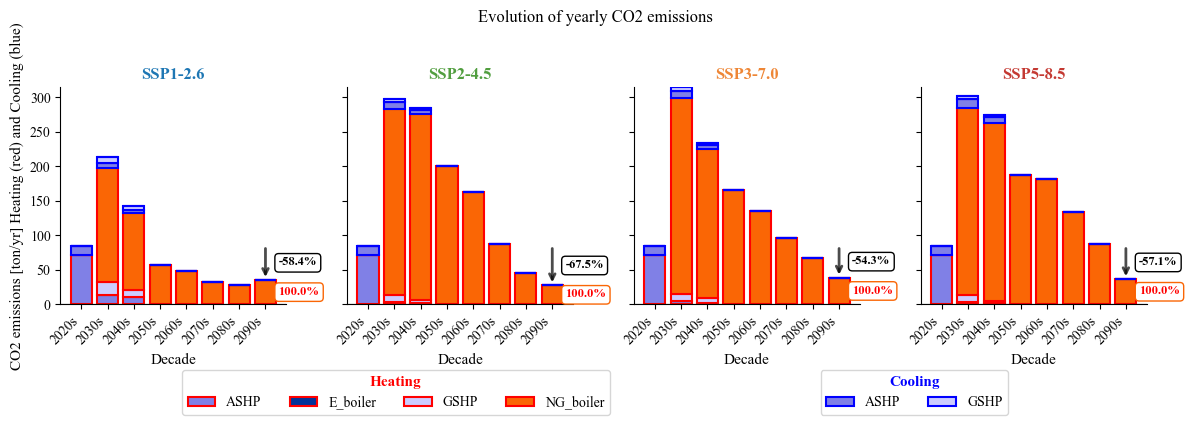

In [9]:
td_opex = pd.read_csv("output/operations/production_details.csv")
td_opex = td_opex[["SSP","Decade","Technology","Day","Hour","Sign","CO2"]].groupby(["SSP","Decade","Technology","Day","Sign","Hour"]).sum().reset_index().rename(columns = {'CO2':'Value'})

joined_df = td_opex.merge(td_weight, on=['SSP', 'Decade', 'Day'])
print(joined_df)
joined_df['Value'] = joined_df['Value'] * joined_df['weight'] / 10 # / 10 years / 1000 kWh -> MWh
df = joined_df.copy()

# Group by SSP, Decade, Technology, Sign and sum values
grouped = df.groupby(['SSP', 'Decade', 'Technology', 'Sign']).agg({
    'Value': 'sum'
}).reset_index()

# Get unique SSPs, Decades, Technologies, and Signs
ssps = df[df['SSP'] != 'past']['SSP'].unique()
print(ssps)
decades = sorted(df['Decade'].unique())
print(decades)
techs = df['Technology'].unique()
print(techs)
signs = df['Sign'].unique()
print(signs)

# Create subplots
fig, axes = plt.subplots(1, len(ssps), figsize=(3*len(ssps), 4), sharey=True)
if len(ssps) == 1:
    axes = [axes]

# Create bar plots for each SSP
for idx, ssp in enumerate(ssps):
    ax = axes[idx]
    ssp_data = grouped[(grouped['SSP'] == ssp) | (grouped['SSP'] == 'past')]
    print(ssp_data)
    
    # Prepare data for stacking - separate by Sign (Heating/Cooling)
    heating_stacks = []
    cooling_stacks = []
    
    for tech in techs:
        tech_data = ssp_data[ssp_data['Technology'] == tech]
        
        # Heating data
        heating_data = tech_data[tech_data['Sign'] == 'Heating']
        heating_summed = heating_data.groupby('Decade').agg({'Value': 'sum'}).reset_index()
        heating_dict = dict(zip(heating_summed['Decade'], heating_summed['Value']))
        heating_stacks.append([heating_dict.get(dec, 0) for dec in decades])
        
        # Cooling data
        cooling_data = tech_data[tech_data['Sign'] == 'Cooling']
        cooling_summed = cooling_data.groupby('Decade').agg({'Value': 'sum'}).reset_index()
        cooling_dict = dict(zip(cooling_summed['Decade'], cooling_summed['Value']))
        cooling_stacks.append([cooling_dict.get(dec, 0) for dec in decades])
    
    # Convert to numpy arrays
    heating_stacks = np.array(heating_stacks)
    cooling_stacks = np.array(cooling_stacks)
    
    # Calculate totals for first and last decade
    first_total_heating = heating_stacks[:, 0].sum()
    last_total_heating = heating_stacks[:, -1].sum()
    first_total_cooling = cooling_stacks[:, 0].sum()
    last_total_cooling = cooling_stacks[:, -1].sum()
    
    # Plot Heating stacks (positive, red edge)
    bottom = np.zeros(len(decades))
    for i, tech in enumerate(techs):
        ax.bar(decades, heating_stacks[i], bottom=bottom, 
               color=tech_colors[tech], label=tech, 
               edgecolor='red', linewidth=1.5)
        bottom += heating_stacks[i]
    
    # Plot Cooling stacks (negative, blue edge)
    # bottom = np.zeros(len(decades))
    for i, tech in enumerate(techs):
        ax.bar(decades, cooling_stacks[i], bottom=bottom, 
               color=tech_colors[tech], edgecolor='blue', linewidth=1.5, label=tech)
        bottom += cooling_stacks[i]
    
    # Add arrow for Heating (from first to last decade total)
    first_decade_x = 0
    last_decade_x = len(decades) - 1
    
    if first_total_heating != 0 or last_total_heating != 0:
        ax.annotate('', xy=(last_decade_x, (last_total_cooling + last_total_heating)), xytext=(last_decade_x, (first_total_cooling+first_total_heating)),
                    arrowprops=dict(arrowstyle='->', lw=2, color='k', alpha=0.7))
        
        if first_total_heating != 0:
            change_pct = 100 * ((last_total_cooling + last_total_heating) - (first_total_cooling+first_total_heating)) / (first_total_cooling+first_total_heating)
            ax.text(last_decade_x+0.5, 0.5*((last_total_cooling + last_total_heating)+(first_total_cooling+first_total_heating)), 
                    f'{change_pct:+.1f}%', 
                    ha='left', va='center', fontsize=9, fontweight='bold',
                    color='black',
                    bbox=dict(facecolor='white', edgecolor='black', 
                                boxstyle='round,pad=0.3'))
    
    
    # Add percentage annotations for last decade - HEATING
    last_heating_stack = heating_stacks[:, -1]
    
    if last_total_heating != 0:
        bottom = 0
        for i, tech in enumerate(techs):
            value = last_heating_stack[i]
            if value != 0:
                percentage = value / (last_total_cooling + last_total_heating) * 100
                y_position = bottom + value / 2
                ax.text(last_decade_x+0.5, y_position, f'{percentage:.1f}%', 
                    ha='left', va='center', fontsize=9, fontweight='bold',
                    color='red',
                    bbox=dict(facecolor='white', edgecolor=tech_colors[tech], 
                                boxstyle='round,pad=0.3'))
                bottom += value
    
    # Add percentage annotations for last decade - COOLING
    last_cooling_stack = cooling_stacks[:, -1]
    
    if last_total_cooling != 0:
        for i, tech in enumerate(techs):
            value = last_cooling_stack[i]
            if value != 0:
                percentage = value / (last_total_cooling + last_total_heating) * 100
                y_position = (bottom + value / 2)
                ax.text(last_decade_x+0.5, y_position, f'{percentage:.1f}%', 
                    ha='left', va='center', fontsize=9, fontweight='bold',
                    color='blue',
                    bbox=dict(facecolor='white', edgecolor=tech_colors[tech], 
                                boxstyle='round,pad=0.3'))
                bottom += value
    
    ssp_formatted = f"SSP{ssp[3]}-{ssp[4]}.{ssp[5]}"
    ax.set_title(f'{ssp_formatted}', fontdict={'color':ssp_colors[ssp_formatted]})
    ax.set_xlabel('Decade')
    if idx == 0:
        ax.set_ylabel('CO2 emissions [ton/yr] Heating (red) and Cooling (blue)')
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.set_xticks(decades)
    ax.set_xticklabels(decades, rotation=45, ha='right')
    # Remove the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)

# Add legend
# Get the original handles and labels
handles, labels = ax.get_legend_handles_labels()

# Define technologies for each legend
heating_techs = range(4)
cooling_techs = [4,6]  # Removed E_boiler and NG_boiler

# Create handles and labels for each legend
heating_handles = [handles[i] for i in heating_techs]
heating_labels = [labels[i] for i in heating_techs]

cooling_handles = [handles[i] for i in cooling_techs]
cooling_labels = [labels[i] for i in cooling_techs]

# Create first legend for Heating
legend1 = fig.legend(heating_handles, heating_labels, 
                     loc='lower left', 
                     title='Heating',
                     title_fontproperties={'weight': 'bold', 'size': 11},
                     bbox_to_anchor=(0.15, -0.05),
                     ncol=len(heating_handles))
legend1.get_title().set_color('red')

# Create second legend for Cooling
legend2 = fig.legend(cooling_handles, cooling_labels, 
                     loc='lower right', 
                     title='Cooling',
                     title_fontproperties={'weight': 'bold', 'size': 11},
                     bbox_to_anchor=(0.85, -0.05),
                     ncol=len(cooling_handles))
legend2.get_title().set_color('blue')

# Adjust layout to make room for legends
plt.tight_layout(rect=[0, 0.1, 1, 0.95])  # Increase bottom margin
fig.suptitle('Evolution of yearly CO2 emissions')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig('output/operations/ssp_view_CO2.png',dpi = 600, bbox_inches='tight')
plt.savefig('output/operations/ssp_view_CO2.pdf', bbox_inches='tight')